In [1]:
# This code works in Python 3.10.6
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
import torch_geometric.transforms as T
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

In [2]:
import torch
from torch_geometric.datasets.dblp import DBLP
import os
import os.path as osp

### DBLP

In [3]:
dataset = DBLP(root='./dblp_data', transform=T.Constant(node_types='conference'))
data = dataset[0]
data

HeteroData(
  author={
    x=[4057, 334],
    y=[4057],
    train_mask=[4057],
    val_mask=[4057],
    test_mask=[4057],
  },
  paper={ x=[14328, 4231] },
  term={ x=[7723, 50] },
  conference={
    num_nodes=20,
    x=[20, 1],
  },
  (author, to, paper)={ edge_index=[2, 19645] },
  (paper, to, author)={ edge_index=[2, 19645] },
  (paper, to, term)={ edge_index=[2, 85810] },
  (paper, to, conference)={ edge_index=[2, 14328] },
  (term, to, paper)={ edge_index=[2, 85810] },
  (conference, to, paper)={ edge_index=[2, 14328] }
)

In [4]:
author = data['author'].x.tolist()
author_df = pd.DataFrame(author)
author_df['class'] = data['author'].y.tolist()

In [5]:
def get_selected_features(X):

    col_sum = X.sum(axis=0)
    sorted_colsum = sorted(col_sum, reverse=True)
    colsum_df = pd.DataFrame(col_sum)
    
    sorted_colsum = sorted(col_sum, reverse=True)[:2]
    index_list = list(np.ravel(colsum_df[colsum_df[0].isin(sorted_colsum)].index))
    
    imp_feat = X[index_list]
    #imp_feat = imp_feat.drop(imp_feat[imp_feat.sum(axis=1) == 0.0].index)


    return imp_feat

### Bag-of-Words features of Author node

In [6]:
author_class0 = author_df[author_df['class'] == 0].drop(['class'], axis = 1)
class0 = get_selected_features(author_class0)
cols = [i for i in range(0,len(class0.columns))]
class0.columns = cols
class0

,0,1
15,0.0,0.0
17,1.0,0.0
30,1.0,0.0
33,1.0,0.0
34,1.0,0.0
...,...,...
4052,1.0,0.0
4053,0.0,0.0
4054,0.0,0.0
4055,0.0,0.0


In [7]:
author_class1 = author_df[author_df['class'] == 1].drop(['class'], axis = 1)
class1 = get_selected_features(author_class1)
cols = [i for i in range(0,len(class1.columns))]
class1.columns = cols
class1

,0,1
4,0.0,0.0
9,0.0,0.0
13,1.0,1.0
23,1.0,0.0
24,0.0,0.0
...,...,...
3667,0.0,0.0
3686,0.0,0.0
3821,1.0,0.0
3956,1.0,0.0


In [8]:
author_class2 = author_df[author_df['class'] == 2].drop(['class'], axis = 1)
class2 = get_selected_features(author_class2)
cols = [i for i in range(0,len(class2.columns))]
class2.columns = cols
class2

,0,1
0,0.0,0.0
1,0.0,0.0
3,1.0,1.0
5,1.0,0.0
6,0.0,0.0
...,...,...
3459,1.0,0.0
3499,0.0,1.0
3515,0.0,1.0
3594,1.0,0.0


In [9]:
author_class3 = author_df[author_df['class'] == 3].drop(['class'], axis = 1)
class3 = get_selected_features(author_class3)
cols = [i for i in range(0,len(class3.columns))]
class3.columns = cols
class3

,0,1
2,1.0,0.0
12,0.0,0.0
20,0.0,1.0
21,1.0,1.0
35,0.0,1.0
...,...,...
3886,0.0,0.0
3887,0.0,0.0
3888,0.0,0.0
3889,0.0,0.0


In [10]:
def sample_features(model,node_type, n_samples):

    smpls = model.sample(n_samples)
    print("no. of class {} node samples - {}".format(node_type, n_samples))
    return smpls[0]

In [11]:
def fit_sample_gm(df_class, node_type, n_samples):
    #fit
    model = GaussianMixture(n_components=1, covariance_type='full', random_state = 0)
    model.fit(df_class)
    #print("Mean for nodetype", node_type,model.means_)
    #sample
    smpls = sample_features(model, node_type, n_samples)
    new_features_dict[node_type] = smpls

In [12]:
def feature_selection(df):
    col_sum = df.sum(axis=0)
    sorted_colsum = sorted(col_sum, reverse=True)

    index_list = []
    for i in sorted_colsum[:1]:
        index_list.append(list(col_sum).index(i))
    imp_feat = df[index_list].reset_index(drop=True)
    return imp_feat

In [13]:
def convert_to_dicrete(df):
    return df.applymap(lambda x: 0.0 if x<0.5 else 1.0)

In [14]:
plt.rcParams.update({'axes.ymargin': 0.2})

In [15]:
def compare_plot_real_syn(df):
    df_new = df.apply(pd.value_counts).T
    print(df_new)
    ax=df_new.plot.bar(width=0.4,figsize=(7,7))
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")
    for i in ax.containers:
        ax.bar_label(i,fontsize=20)
    
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.legend(fontsize="20", loc ="lower center")
    plt.ylabel('no. of samples',fontsize=20)   
    plt.tight_layout()
    plt.show()
    plt.clf() 

In [16]:
def cosine_sim(original,sampled):
    return cosine_similarity(np.array(original), np.array(sampled))

### Fit Gaussian Mixture Models to 4 Author node classes

In [17]:
new_features_dict = {}

In [18]:
fit_sample_gm(class0, 'author0', class0.shape[0])
fit_sample_gm(class1, 'author1', class1.shape[0])
fit_sample_gm(class2, 'author2', class2.shape[0])
fit_sample_gm(class3, 'author3', class3.shape[0])

no. of class author0 node samples - 1197
no. of class author1 node samples - 745
no. of class author2 node samples - 1109
no. of class author3 node samples - 1006


### Continuous features sampled using Gaussian Mixure Models

In [19]:
sampled0  = pd.DataFrame(new_features_dict['author0'])
sampled0.head()

,0,1
0,-0.399434,0.053768
1,-0.521790,1.002280
2,-0.099180,-0.525465
3,0.089510,0.052497
4,0.402844,0.561432


In [20]:
sampled1  = pd.DataFrame(new_features_dict['author1'])
sampled1.head()

,0,1
0,-0.291191,-0.112255
1,-0.520209,0.746029
2,0.074612,-0.558815
3,0.198792,0.054712
4,0.455589,0.645587


In [21]:
sampled2  = pd.DataFrame(new_features_dict['author2'])
sampled2.head()

,0,1
0,-0.424547,-0.240032
1,-0.725366,0.537143
2,-0.044810,-0.651336
3,0.000704,-0.103896
4,0.168709,0.419470


In [22]:
sampled3  = pd.DataFrame(new_features_dict['author3'])
sampled3.head()

,0,1
0,-0.456565,-0.230829
1,-0.616125,0.554158
2,-0.141551,-0.608578
3,0.015180,-0.011640
4,0.295177,0.580322


### Sampled continuous features are converted to discrete using a threshold

In [23]:
authorclass0_sampled = convert_to_dicrete(pd.DataFrame(new_features_dict['author0']))
authorclass0_sampled.head()

,0,1
0,0.0,0.0
1,0.0,1.0
2,0.0,0.0
3,0.0,0.0
4,0.0,1.0


In [24]:
authorclass1_sampled = convert_to_dicrete(pd.DataFrame(new_features_dict['author1']))
authorclass1_sampled.head()

,0,1
0,0.0,0.0
1,0.0,1.0
2,0.0,0.0
3,0.0,0.0
4,0.0,1.0


In [25]:
authorclass2_sampled = convert_to_dicrete(pd.DataFrame(new_features_dict['author2']))
authorclass2_sampled.head()

,0,1
0,0.0,0.0
1,0.0,1.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0


In [26]:
authorclass3_sampled = convert_to_dicrete(pd.DataFrame(new_features_dict['author3']))
authorclass3_sampled.head()

,0,1
0,0.0,0.0
1,0.0,1.0
2,0.0,0.0
3,0.0,0.0
4,0.0,1.0


### Pairwise cosine similarity of all features for real and synthetic distributions

Author class 0

In [27]:
cosine_sim(class0,authorclass0_sampled)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [28]:
sns.set(font_scale=1.4)

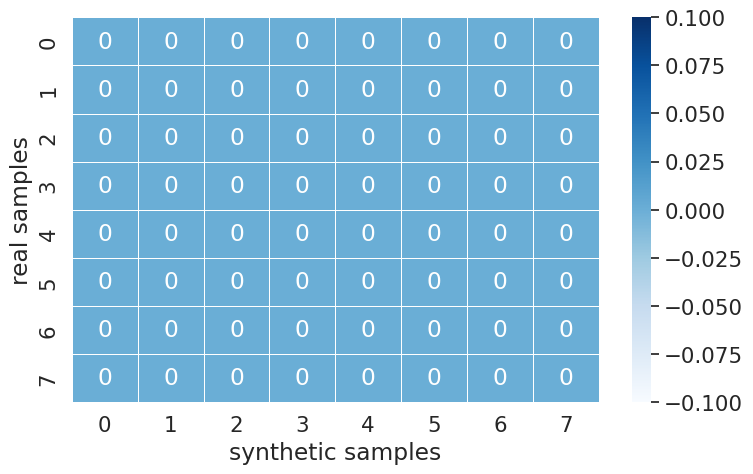

In [29]:
fig, ax = plt.subplots(figsize=(8.5,5)) 
sns.heatmap(cosine_sim(class0.iloc[:8],authorclass0_sampled[:8]), 
            xticklabels = 1, yticklabels = 1, annot=True, cmap='Blues', linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [30]:
avg_cossim_class0 = np.mean(cosine_sim(class0,authorclass0_sampled))
avg_cossim_class0

0.2737083016299806

Author class 1

In [31]:
cosine_sim(class1,authorclass1_sampled)

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.70710678, 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

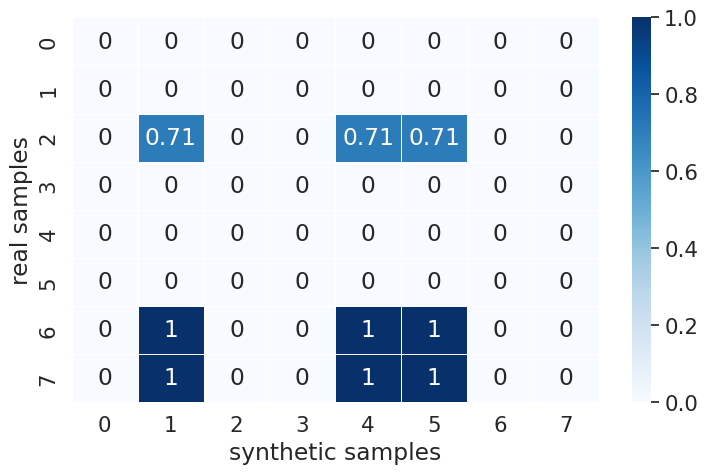

In [32]:
fig, ax = plt.subplots(figsize=(8.5,5))
sns.heatmap(cosine_sim(class1.iloc[:8],authorclass1_sampled[:8]), 
            xticklabels = 1, yticklabels = 1, annot=True, cmap='Blues', linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [33]:
avg_cossim_class1 = np.mean(cosine_sim(class1,authorclass1_sampled))
avg_cossim_class1

0.34109564891678

Author class 2

In [34]:
cosine_sim(class2,authorclass2_sampled)

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.70710678, 0.        , ..., 0.70710678, 0.70710678,
        0.        ],
       ...,
       [0.        , 1.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 1.        , 1.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

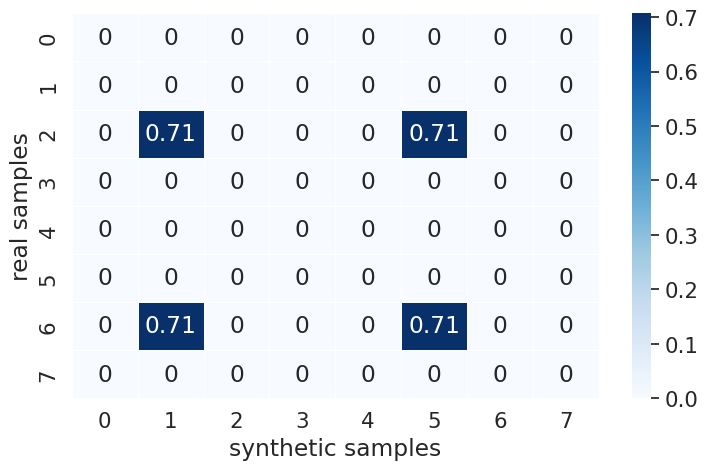

In [35]:
fig, ax = plt.subplots(figsize=(8.5,5))
sns.heatmap(cosine_sim(class2.iloc[:8],authorclass2_sampled[:8]), 
            xticklabels = 1, yticklabels = 1, annot=True, cmap='Blues', linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [36]:
avg_cossim_class2 = np.mean(cosine_sim(class2,authorclass2_sampled))
avg_cossim_class2

0.12982529328528788

Author class 3

In [37]:
cosine_sim(class3,authorclass3_sampled)

array([[0.        , 0.        , 0.        , ..., 0.70710678, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.        , 0.        , ..., 0.70710678, 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

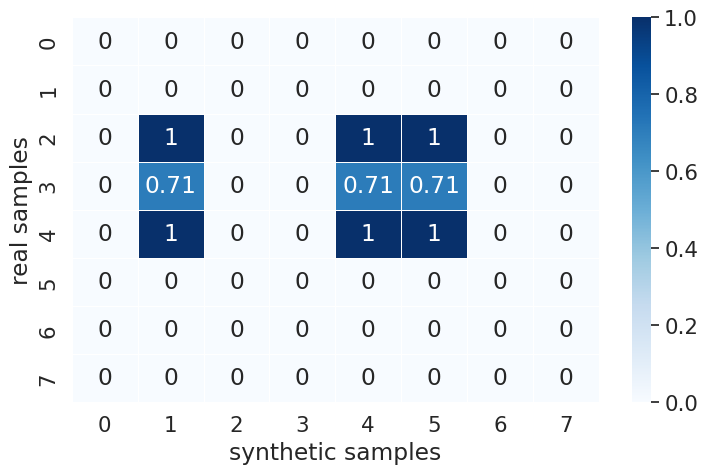

In [38]:
fig, ax = plt.subplots(figsize=(8.5,5))
sns.heatmap(cosine_sim(class3.iloc[:8],authorclass3_sampled[:8]), 
            xticklabels = 1, yticklabels = 1, annot=True, cmap='Blues', linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [39]:
avg_cossim_class3 = np.mean(cosine_sim(class3,authorclass3_sampled))
avg_cossim_class3

0.22540726981512965

In [40]:
(avg_cossim_class0 + avg_cossim_class1 +avg_cossim_class2 + avg_cossim_class3)/4

0.24250912841179456